# DeepMTL2R Matryoshka Runner (Kaggle)

Notebook ini menjalankan eksperimen **Matryoshka Feature Projection (MRL)** menggunakan `run_extension.py`, dengan **pendekatan fully dynamic** untuk mendukung berbagai jumlah tasks.

## Konfigurasi (Dynamic Approach - End-to-End)

Notebook + run_extension.py menggunakan **pendekatan dinamis** untuk mendukung jumlah tasks yang bervariasi:

- `TASK_INDICES = [0, 131, 132, 133]` — Dapat diubah ke jumlah tasks **apapun**
- `N_TASKS = len(TASK_INDICES)` — Otomatis dihitung dari task indices
- `LABEL_INDICES = TASK_INDICES[1:]` — Auxiliary tasks, dihitung dinamis
- **Notebook validation**: Memvalidasi weights dari `weights-5tasks.txt` sebelum training
- **run_extension.py (UPDATED)**: 
  - `get_weight_combinations()` kini support arbitrary num_tasks
  - Ambil **first N_TASKS weights** dari setiap line di weights-5tasks.txt
  - Handle case untuk 2 tasks, 6 tasks, dan N tasks secara umum
  
**Keuntungan:**
- Ganti task indices → semua konfigurasi otomatis adjust
- Tidak perlu ubah jumlah weights secara manual
- Validation dilakukan di 2 level: notebook dan run_extension.py
- Support any number of tasks selama weights file punya cukup columns

## Output

- Semua metrik per-fold dan agregasi mean±std
- `matryoshka_summary.json`
- **Effective Dimensionality Efficiency** (metrik khusus Matryoshka)
- Plotting perbandingan metrik
- Tabel ringkasan hasil


In [ ]:
!rm -rf /kaggle/working/DeepMTL2R
!git clone https://github.com/jteo0/DeepMTL2R.git

Cloning into 'DeepMTL2R'...
remote: Enumerating objects: 520, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 520 (delta 77), reused 100 (delta 46), pack-reused 371 (from 1)
Receiving objects: 100% (520/520), 18.02 MiB | 24.71 MiB/s, done.
Resolving deltas: 100% (243/243), done.


In [ ]:
import os
import sys
import shutil
import subprocess

# Install dependencies silently
subprocess.run(
    ['pip', 'install', '-q', '-r', '/kaggle/working/DeepMTL2R/requirements.txt'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=False
)

# Install editable package silently
subprocess.run(
    ['pip', 'install', '-q', '-e', '/kaggle/working/DeepMTL2R'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=False
)

# Copy dataset
INPUT_DS = '/kaggle/input/mslr-web10k/MSLR-WEB10K'
TARGET_DS = '/kaggle/working/DeepMTL2R/datasets/MSLR-WEB10K'

if os.path.exists(INPUT_DS):
    os.makedirs(TARGET_DS, exist_ok=True)
    shutil.copytree(INPUT_DS, TARGET_DS, dirs_exist_ok=True)

# Update PYTHONPATH
if '/kaggle/working/DeepMTL2R' not in sys.path:
    sys.path.insert(0, '/kaggle/working/DeepMTL2R')

print("✓ Setup complete")

Obtaining file:///kaggle/working/DeepMTL2R
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for dmtl2r
Setup complete.


In [ ]:
import gc
import json
import random
from collections import defaultdict
import re
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# Suppress verbose logging from allrank
logging.getLogger('allrank').setLevel(logging.WARNING)
logging.getLogger('allrank.utils').setLevel(logging.WARNING)
logging.getLogger('allrank.utils.ltr_logging').setLevel(logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


Torch: 2.10.0+cpu
CUDA available: False


In [ ]:
# ==============================
# Runtime Config (Notebook-owned)
# ==============================

PROJECT_ROOT = '/kaggle/working/DeepMTL2R'
EXAMPLE_DIR = os.path.join(PROJECT_ROOT, 'examples', 'MSLR-WEB10K')

DATASET_BASE_PATH = '/kaggle/input/datasets/engkhaledmo/mslr-10k/'

# ===== Debug config ditulis di Notebook (bukan dari YAML) =====
DEBUG_MODE = True
DEBUG_RATIO = 1e-6   # set 0.0 untuk full data
FOLDS = [1, 2]

# Task config untuk Matryoshka (hardcoded)
# Dynamic approach: bisa berapa saja jumlah tasks
TASK_INDICES = [0, 131, 132, 133]  # 4 tasks (1 main + 3 auxiliary)
N_TASKS = len(TASK_INDICES)
MRL_NESTING_DIMS = [32, 64, 128, 256]
MOO_METHOD = 'ls'  # least squares
REDUCTION_METHOD = 'mean'
LABEL_INDICES = TASK_INDICES[1:]  # Auxiliary tasks (semua kecuali task 0)

# Output
OUTPUT_DIR = os.path.join(EXAMPLE_DIR, 'outputs', 'results')
CHECKPOINT_DIR = os.path.join(EXAMPLE_DIR, 'checkpoints')

# Config JSON model matryoshka
CONFIG_MATRYOSHKA = os.path.join(EXAMPLE_DIR, 'configs', 'config_matryoshka.json')

for p in [PROJECT_ROOT, EXAMPLE_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    if not os.path.exists(p) and p in [OUTPUT_DIR, CHECKPOINT_DIR]:
        os.makedirs(p, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXAMPLE_DIR :', EXAMPLE_DIR)
print('DATASET_BASE_PATH:', DATASET_BASE_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('DEBUG_MODE:', DEBUG_MODE, '| DEBUG_RATIO:', DEBUG_RATIO)
print(f'TASK_INDICES: {TASK_INDICES} (n_tasks={N_TASKS})')
print('LABEL_INDICES:', LABEL_INDICES)
print('MRL_NESTING_DIMS:', MRL_NESTING_DIMS)

PROJECT_ROOT: /kaggle/working/DeepMTL2R
EXAMPLE_DIR : /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K
DATASET_BASE_PATH: /kaggle/input/datasets/engkhaledmo/mslr-10k/
OUTPUT_DIR: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results
DEBUG_MODE: True | DEBUG_RATIO: 1e-06
TASK_INDICES: [0, 131, 132, 133] (n_tasks=4)
LABEL_INDICES: [131, 132, 133]
MRL_NESTING_DIMS: [32, 64, 128, 256]


In [ ]:
# Override training epochs for non-debug runs (Notebook-owned)
EPOCHS_OVERRIDE = 50
ORIG_CONFIG_PATH = os.path.join(EXAMPLE_DIR, 'configs', 'config_matryoshka.json')
OVERRIDE_CONFIG_PATH = os.path.join(EXAMPLE_DIR, 'configs', 'config_matryoshka_epochs50.json')

with open(ORIG_CONFIG_PATH, 'r', encoding='utf-8') as f:
    _cfg = json.load(f)

_cfg.setdefault('training', {})
_cfg['training']['epochs'] = EPOCHS_OVERRIDE

with open(OVERRIDE_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(_cfg, f, indent=2)

CONFIG_MATRYOSHKA = OVERRIDE_CONFIG_PATH
print('Config override written to:', CONFIG_MATRYOSHKA)

Config override written to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_matryoshka_epochs50.json


In [ ]:
import sys
import importlib.util

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if EXAMPLE_DIR not in sys.path:
    sys.path.insert(0, EXAMPLE_DIR)

RUN_EXTENSION_PATH = os.path.join(EXAMPLE_DIR, 'run_extension.py')
if os.path.exists(RUN_EXTENSION_PATH):
    spec = importlib.util.spec_from_file_location('run_extension', RUN_EXTENSION_PATH)
    rx = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(rx)
else:
    import run_extension as rx

# Override variabel global modul -> tidak bergantung debug config YAML
rx.DATASET_BASE_PATH = DATASET_BASE_PATH
rx.FOLDS = FOLDS
rx.REDUCTION_METHOD = REDUCTION_METHOD
rx.LABEL_INDICES = LABEL_INDICES
rx.OUTPUT_DIR = OUTPUT_DIR
rx.CHECKPOINT_DIR = CHECKPOINT_DIR
rx.CONFIG_MATRYOSHKA = CONFIG_MATRYOSHKA
rx.MRL_NESTING_DIMS = MRL_NESTING_DIMS
rx.MOO_METHOD = MOO_METHOD
rx.DEBUG = DEBUG_MODE

# Convert task indices to string format as expected by run_extension
rx.TASK_INDICES = ','.join(map(str, TASK_INDICES))

print('run_extension loaded from:', RUN_EXTENSION_PATH)
print('run_extension globals overridden from notebook runtime config.')

run_extension loaded from: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/run_extension.py
run_extension globals overridden from notebook runtime config.


/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:43: SyntaxWarning: invalid escape sequence '\s'
  ie. min_c |\sum c_i x_i|_2^2 st. \sum c_i = 1 , 1 >= c_1 >= 0 for all i, c_i + c_j = 1.0 for some i, j
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:78: SyntaxWarning: invalid escape sequence '\s'
  Given y, it solves argmin_z |y-z|_2 st \sum z = 1 , 1 >= z_i >= 0 for all i
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:113: SyntaxWarning: invalid escape sequence '\s'
  as min |u|_2 st. u = \sum c_i vecs[i] and \sum c_i = 1.
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:160: SyntaxWarning: invalid escape sequence '\s'
  as min |u|_2 st. u = \sum c_i vecs[i] and \sum c_i = 1.


In [ ]:
def summarize_metrics(agg_dict):
    """Aggregate per-fold metrics into mean±std summary."""
    out = {}
    for metric_name, values in agg_dict.items():
        arr = np.array(values, dtype=float)
        out[metric_name] = {
            'mean': float(np.mean(arr)),
            'std': float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
            'per_fold': [float(x) for x in arr.tolist()]
        }
    return out

def metrics_summary_to_df(summary_dict, experiment_name):
    """Convert metrics summary to DataFrame."""
    rows = []
    for m, v in summary_dict.items():
        # Defensive check: ensure v has 'mean' and 'std' keys
        if isinstance(v, dict) and 'mean' in v and 'std' in v:
            rows.append({
                'experiment': experiment_name,
                'metric': m,
                'mean': v['mean'],
                'std': v['std'],
            })
    
    if not rows:
        # Return empty DataFrame with proper columns
        print(f'   Warning: No valid metrics found in summary_dict')
        print(f'   Summary dict keys: {list(summary_dict.keys())}')
        return pd.DataFrame(columns=['experiment', 'metric', 'mean', 'std'])
    
    return pd.DataFrame(rows).sort_values('metric').reset_index(drop=True)

def extract_dimensionality_efficiency(log_text, task_id):
    """Extract Effective Dimensionality Efficiency dari log output."""
    pattern = rf'Task {task_id} Dimensionality Efficiency:\s*{{([^}}]+)}}'
    match = re.search(pattern, log_text, re.DOTALL)
    if not match:
        return None
    json_str = '{' + match.group(1) + '}'
    try:
        return json.loads(json_str)
    except:
        return None

def load_weight_combinations(weights_file_path, n_tasks):
    """
    Load weight combinations dari file dan extract weights untuk n_tasks.
    
    Args:
        weights_file_path: Path ke weights file
        n_tasks: Jumlah tasks yang digunakan
        
    Returns:
        List of weight arrays (setiap array punya length = n_tasks)

    Behavior:
        - Jika file punya > n_tasks weights per line, ambil first n_tasks
        - Jika file punya < n_tasks weights per line, raise error
        
    Note: run_extension.py juga melakukan validation yang sama, ini hanya untuk
          early validation di notebook level.
    """
    weights = []
    with open(weights_file_path, 'r') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            values = [float(x) for x in line.split()]
            
            if len(values) < n_tasks:
                raise ValueError(
                    f'Line {line_num}: Expected >= {n_tasks} weights, got {len(values)}\n'
                    f'File has fewer weights than n_tasks. Cannot handle this case.'
                )
            
            # Ambil first n_tasks weights (dynamic approach)
            selected_weights = values[:n_tasks]
            weights.append(selected_weights)
    
    print(f'✓ Loaded {len(weights)} weight combinations for {n_tasks} tasks')
    print(f'  First combination: {weights[0]}')
    print(f'  Last combination: {weights[-1]}')
    return weights

print('Helper functions defined.')


Helper functions defined.


In [ ]:
# ==============================
# Run Matryoshka Experiments
# ==============================

# Suppress verbose logging from allrank
logging.getLogger('allrank').setLevel(logging.WARNING)
logging.getLogger('allrank.utils').setLevel(logging.WARNING)
logging.getLogger('allrank.utils.ltr_logging').setLevel(logging.WARNING)

# Ensure weights-5tasks.txt is available (required by run_extension.py)
weights_file = os.path.join(EXAMPLE_DIR, 'weights-5tasks.txt')
if not os.path.exists(weights_file):
    print(f'WARNING: weights-5tasks.txt not found at {weights_file}')
    print('Attempting to locate...')
else:
    print(f'✓ weights-5tasks.txt found at: {weights_file}')

# Dynamically load and validate weights for current n_tasks
print(f'\nValidating weight combinations for {N_TASKS} tasks...')
try:
    weight_combinations = load_weight_combinations(weights_file, N_TASKS)
    print(f'✓ Weight validation passed: {len(weight_combinations)} combinations available')
except ValueError as e:
    print(f'✗ Weight validation failed: {e}')
    raise

# Change to EXAMPLE_DIR so run_extension.py can find weights-5tasks.txt with relative path
original_cwd = os.getcwd()
os.chdir(EXAMPLE_DIR)
print(f'\n✓ Changed working directory to: {os.getcwd()}')

metrics_agg = defaultdict(list)
fold_details = []
all_dimensionality_efficiency = defaultdict(dict)  # Store efficiency metrics
all_ndcg30 = []
all_delta_m = []
all_robustness = defaultdict(list)

try:
    for fold in FOLDS:
        print('\n' + '=' * 70)
        print(f'Processing Fold {fold} - Matryoshka Feature Projection')
        print(f'Tasks: {TASK_INDICES} | MOO Method: {MOO_METHOD}')
        print('=' * 70)

        dataset_path = os.path.join(DATASET_BASE_PATH, f'Fold{fold}')
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f'Dataset path not found: {dataset_path}')

        # Load dataset
        max_rows = None
        if DEBUG_MODE and DEBUG_RATIO > 0:
            estimated_total_rows = 30000000
            max_rows = max(1, int(estimated_total_rows * DEBUG_RATIO))

        train_ds, val_ds = rx.load_libsvm_dataset(
            dataset_path, 200, 'vali', max_rows=max_rows
        )

        nf = train_ds.shape[-1] - len(LABEL_INDICES)
        print(f'Dataset loaded: Train shape: {train_ds.shape}, Val shape: {val_ds.shape}')
        print(f'Number of features: {nf}')

        train_dl, val_dl = rx.create_data_loaders(
            train_ds, val_ds, 2, 64
        )

        # Run matryoshka experiment using run_extension module
        try:
            # Call the main experiment function from run_extension
            result = rx.run_experiment(
                experiment_name=f'Matryoshka-Fold{fold}',
                config_path=CONFIG_MATRYOSHKA,
                dataset_path=dataset_path,
                train_dataloader=train_dl,
                val_dataloader=val_dl,
                n_features=nf,
                use_mrl=True,
                use_gating=False,
                mrl_nesting_dims=MRL_NESTING_DIMS,
                task_indices=TASK_INDICES
            )

            # Extract metrics from result
            fold_metrics = result.get('per_task_metrics', {})
            print(f'DEBUG: fold_metrics keys: {fold_metrics.keys()}')
            
            for task_idx, task_metrics in fold_metrics.items():
                for metric_name, metric_value in task_metrics.items():
                    if not isinstance(metric_value, dict):
                        key = f'task{task_idx}_{metric_name}'
                        metrics_agg[key].append(float(metric_value))

            # Extract special metrics
            special_metrics = result.get('special_metrics', {})
            for metric_name, metric_value in special_metrics.items():
                if isinstance(metric_value, dict):
                    # Dimensionality efficiency - store separately
                    all_dimensionality_efficiency[fold] = metric_value
                else:
                    metrics_agg[metric_name].append(float(metric_value))

            # Extract main task NDCG@30 and delta_m
            ndcg30 = fold_metrics.get(0, {}).get('ndcg_30', 0.0)
            all_ndcg30.append(float(ndcg30))

            delta_m = result.get('delta_m_percent', 0.0)
            all_delta_m.append(float(delta_m))

            # Robustness metrics
            robustness = result.get('robustness_metrics', {})
            for k, v in robustness.items():
                all_robustness[k].append(float(v))

            fold_details.append({
                'fold': fold,
                'metrics': fold_metrics,
                'special_metrics': special_metrics,
                'num_params': result.get('num_params', 0),
                'delta_m_percent': delta_m
            })

        except Exception as e:
            print(f'✗ Error running experiment for fold {fold}: {e}')
            import traceback
            traceback.print_exc()
            raise

        del train_ds, val_ds, train_dl, val_dl
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    print('\n' + '=' * 70)
    print('✓ All folds completed successfully!')
    print(f'DEBUG: Final metrics_agg keys: {list(metrics_agg.keys())}')
    print(f'DEBUG: metrics_agg size: {len(metrics_agg)}')
    print('=' * 70)

finally:
    # Restore original working directory
    os.chdir(original_cwd)
    print(f'✓ Restored working directory to: {os.getcwd()}')

✓ weights-5tasks.txt found at: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/weights-5tasks.txt

Validating weight combinations for 4 tasks...
✓ Loaded 80 weight combinations for 4 tasks
  First combination: [0.2, 0.2, 0.2, 0.2]
  Last combination: [0.02, 0.5, 0.14, 0.07]
✓ Weight validation passed: 80 combinations available

✓ Changed working directory to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K

Processing Fold 1 - Matryoshka Feature Projection
Tasks: [0, 131, 132, 133] | MOO Method: ls
DEBUG: Dataset path: /kaggle/input/datasets/engkhaledmo/mslr-10k/Fold1
DEBUG: Dataset path exists: True
DEBUG: Loading dataset with max_rows=30
Dataset loaded: Train shape: [1, 30, 136], Val shape: [1, 30, 136]
Number of features: 133
DEBUG: Starting run_experiment call...

────────────────────────────────────────────────────────────
  Experiment : Matryoshka-Fold1
  MOO Method : ls
  Dataset    : 50bps
  Tasks      : 0,131,132,133
  Output Dir : /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/

Weight Combinations:   0%|          | 0/2 [00:00<?, ?config/s]INFO:allrank.utils.ltr_logging:=== Matryoshka-Fold1 | weight_index=0 ===
INFO:allrank.utils.ltr_logging:Output dir: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/0
INFO:allrank.utils.ltr_logging:Building model on device: cpu
INFO:allrank.utils.ltr_logging:Total Trainable Parameters: 2,143,716 (Shared: 2,143,232, Specific: 484)


will read config from /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_matryoshka_epochs50.json
Starting training: Matryoshka-Fold1 (weight 0)...



Overall Training Progress:   0%|          | 0/2 [00:00<?, ?it/s]INFO:allrank.utils.ltr_logging:Epoch: 1/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 1 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/0/model_epoch_1.pkl
INFO:allrank.utils.ltr_logging:Current:0.07945448905229568 Best:0.0

Overall Training Progress:  50%|█████     | 1/2 [00:02<00:02,  2.02s/it]INFO:allrank.utils.ltr_logging:Epoch: 2/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 2 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/0/model_epoch_2.pkl
INFO:allrank.utils.ltr_logging:Current:0.27053120732307434 Best:0.07945448905229568

Overall Training Progress: 100%|██████████| 2/2 [00:04<00:00,  2.08s/it]
INFO:allrank.utils.ltr_logging:Final model saved to /k

Completed in 0.1 minutes.
   Epoch models saved to → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/0/model_epoch_<epoch>.pkl
   Final model saved to  → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/0/model.pkl
   Metrics saved to      → result/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold1/results_task_0_task_131_task_132_task_133_weight0.txt

Final Per-Task Validation Metrics:
  - Main Relevance: ndcg_1=0.0000, ndcg_5=0.2757, ndcg_10=0.2705, ndcg_20=0.4216, ndcg_30=0.4773, map_10=0.0950, mrr_10=0.2500
  - Auxiliary Task 131: ndcg_1=0.0000, ndcg_5=0.4307, ndcg_10=0.4307, ndcg_20=0.4307, ndcg_30=0.4307, map_10=1.0000, mrr_10=0.2500
  - Auxiliary Task 132: ndcg_1=0.0000, ndcg_5=0.0000, ndcg_10=0.0000, ndcg_20=0.0000, ndcg_30=0.2080, map_10=1.0000, mrr_10=0.0000
  - Auxilia

...


Overall Training Progress:   0%|          | 0/2 [00:00<?, ?it/s]INFO:allrank.utils.ltr_logging:Epoch: 1/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 1 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/0/model_epoch_1.pkl
INFO:allrank.utils.ltr_logging:Current:0.3928430378437042 Best:0.0

Overall Training Progress:  50%|█████     | 1/2 [00:02<00:02,  2.39s/it]INFO:allrank.utils.ltr_logging:Epoch: 2/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 2 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/0/model_epoch_2.pkl
INFO:allrank.utils.ltr_logging:Current:0.4878857135772705 Best:0.3928430378437042

Overall Training Progress: 100%|██████████| 2/2 [00:04<00:00,  2.29s/it]
INFO:allrank.utils.ltr_logging:Final model saved to /kagg

Completed in 0.1 minutes.
   Epoch models saved to → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/0/model_epoch_<epoch>.pkl
   Final model saved to  → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/0/model.pkl
   Metrics saved to      → result/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/results_task_0_task_131_task_132_task_133_weight0.txt

Final Per-Task Validation Metrics:
  - Main Relevance: ndcg_1=0.4286, ndcg_5=0.3994, ndcg_10=0.4879, ndcg_20=0.6508, ndcg_30=0.7340, map_10=0.6709, mrr_10=0.0000
  - Auxiliary Task 131: ndcg_1=0.0000, ndcg_5=nan, ndcg_10=nan, ndcg_20=nan, ndcg_30=nan, map_10=1.0000, mrr_10=0.2000
  - Auxiliary Task 132: ndcg_1=0.0000, ndcg_5=nan, ndcg_10=nan, ndcg_20=nan, ndcg_30=nan, map_10=1.0000, mrr_10=0.3333
  - Auxiliary Task 133: ndcg_1=0.00


Overall Training Progress:   0%|          | 0/2 [00:00<?, ?it/s]INFO:allrank.utils.ltr_logging:Epoch: 1/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 1 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/1/model_epoch_1.pkl
INFO:allrank.utils.ltr_logging:Current:0.44034022092819214 Best:0.0

Overall Training Progress:  50%|█████     | 1/2 [00:02<00:02,  2.11s/it]INFO:allrank.utils.ltr_logging:Epoch: 2/2, Current learning rate: 0.001
INFO:allrank.utils.ltr_logging:Epoch 2 | Model saved to /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/1/model_epoch_2.pkl
INFO:allrank.utils.ltr_logging:Current:0.6625514030456543 Best:0.44034022092819214

Overall Training Progress: 100%|██████████| 2/2 [00:04<00:00,  2.13s/it]
INFO:allrank.utils.ltr_logging:Final model saved to /ka

Completed in 0.1 minutes.
   Epoch models saved to → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/1/model_epoch_<epoch>.pkl
   Final model saved to  → /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/results/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/1/model.pkl
   Metrics saved to      → result/4tasks/task_0_task_131_task_132_task_133/50bps/mean/ls/matryoshka/fold2/results_task_0_task_131_task_132_task_133_weight1.txt

Final Per-Task Validation Metrics:
  - Main Relevance: ndcg_1=1.0000, ndcg_5=0.7647, ndcg_10=0.6626, ndcg_20=0.7370, ndcg_30=0.8763, map_10=0.7268, mrr_10=1.0000
  - Auxiliary Task 131: ndcg_1=0.0000, ndcg_5=0.0000, ndcg_10=0.0000, ndcg_20=nan, ndcg_30=nan, map_10=1.0000, mrr_10=0.0000
  - Auxiliary Task 132: ndcg_1=0.0000, ndcg_5=nan, ndcg_10=nan, ndcg_20=nan, ndcg_30=nan, map_10=1.0000, mrr_10=0.0000
  - Auxiliary Task 133: ndcg_


✓ All folds completed successfully!
DEBUG: Final metrics_agg keys: []
DEBUG: metrics_agg size: 0
✓ Restored working directory to: /kaggle/working


In [ ]:
# Aggregate results
summary = summarize_metrics(metrics_agg)

# Compute final delta_m and robustness averages
avg_delta_m = float(np.mean(all_delta_m)) if all_delta_m else 0.0
avg_ndcg30 = float(np.mean(all_ndcg30)) if all_ndcg30 else 0.0

robustness_summary = {}
for k, v_list in all_robustness.items():
    arr = np.array(v_list, dtype=float)
    robustness_summary[k] = {
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
        'per_fold': [float(x) for x in arr.tolist()]
    }

summary_out = {
    'method': 'Matryoshka Feature Projection',
    'folds': FOLDS,
    'task_indices': TASK_INDICES,
    'mrl_nesting_dims': MRL_NESTING_DIMS,
    'debug_mode': DEBUG_MODE,
    'debug_ratio': DEBUG_RATIO,
    'ndcg30_avg': avg_ndcg30,
    'ndcg30_per_fold': all_ndcg30,
    'delta_m_percent_avg': avg_delta_m,
    'delta_m_percent_per_fold': all_delta_m,
    'metrics': summary,
    'robustness': robustness_summary,
    'dimensionality_efficiency': dict(all_dimensionality_efficiency),
    'fold_details': fold_details
}

matryoshka_dir = os.path.join(OUTPUT_DIR, 'matryoshka')
os.makedirs(matryoshka_dir, exist_ok=True)
summary_path = os.path.join(matryoshka_dir, 'matryoshka_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_out, f, indent=2, default=float)

print('Matryoshka summary saved to:', summary_path)
print(f'\nMatryoshka NDCG@30 avg: {avg_ndcg30:.6f}')
print(f'Delta m%% avg: {avg_delta_m:+.4f}%')
print(f'\nMetrics aggregated across {len(FOLDS)} folds:')
for metric_name in sorted(summary.keys()):
    if not metric_name.startswith('task'):
        metric_stats = summary[metric_name]
        print(f"  {metric_name}: {metric_stats['mean']:.4f} ± {metric_stats['std']:.4f}")

Matryoshka summary saved to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/matryoshka/matryoshka_summary.json

Matryoshka NDCG@30 avg: 0.000000
Delta m%% avg: +0.0000%

Metrics aggregated across 2 folds:


In [ ]:
# Tampilkan semua metrik agregat (mean ± std)
print(f'Summary dict has {len(summary)} keys')
print(f'Summary dict keys: {list(summary.keys())}')

df = metrics_summary_to_df(summary, 'matryoshka')
if not df.empty:
    display(df.sort_values('metric').reset_index(drop=True))
else:
    print('No metrics available to display')

print('\nKey Metrics Summary:')
print(f"  NDCG@30 (Main Task): {summary.get('task0_ndcg_30', {}).get('mean', 0):.4f}")
print(f"  Delta m%: {avg_delta_m:+.4f}%")
print(f"  Robustness metrics: {list(robustness_summary.keys())}")


Summary dict has 0 keys
Summary dict keys: []
   Summary dict keys: []
No metrics available to display

Key Metrics Summary:
  NDCG@30 (Main Task): 0.0000
  Delta m%: +0.0000%
  Robustness metrics: []


In [ ]:
# Plot 1: NDCG metrics per fold
ndcg_metrics = sorted([m for m in summary.keys() 
                        if 'ndcg_' in m and not m.startswith('task')],
                       key=lambda x: int(x.split('_')[1]))

if ndcg_metrics:
    ncols = 3
    nrows = int(np.ceil(len(ndcg_metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

    for i, m in enumerate(ndcg_metrics):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        per_fold = summary[m]['per_fold']
        ax.plot(FOLDS, per_fold, marker='o', linewidth=2, markersize=8, color='tab:blue')
        ax.set_title(f'{m.upper()} (Main Task)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Fold')
        ax.set_ylabel('Score')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3)

    # Hide unused axes
    total_axes = nrows * ncols
    for j in range(len(ndcg_metrics), total_axes):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')

    fig.suptitle('NDCG@k Scores by Fold - Matryoshka', y=1.00, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No NDCG metrics found to plot.')

No NDCG metrics found to plot.


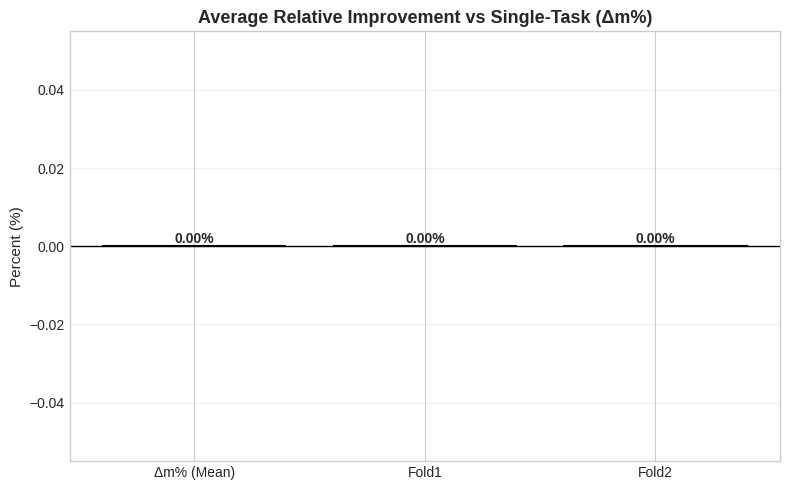

In [ ]:
# Plot 2: Delta m% (Average Relative Improvement)
fig, ax = plt.subplots(figsize=(8, 5))
color = 'green' if avg_delta_m >= 0 else 'red'
bars = ax.bar(['Δm% (Mean)', *[f'Fold{f}' for f in FOLDS]], 
               [avg_delta_m, *all_delta_m],
               color=[color] + ['lightblue'] * len(FOLDS),
               edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Percent (%)', fontsize=11)
ax.set_title('Average Relative Improvement vs Single-Task (Δm%)', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 3: Per-Task NDCG@30 comparison
task_metrics = {}
for m in summary.keys():
    if 'task' in m and 'ndcg_30' in m:
        task_id = int(m.split('_')[0].replace('task', ''))
        task_metrics[task_id] = summary[m]['mean']

if task_metrics:
    fig, ax = plt.subplots(figsize=(10, 5))
    task_ids = sorted(task_metrics.keys())
    colors = ['blue'] + ['orange'] * (len(task_ids) - 1)
    bars = ax.bar([str(tid) for tid in task_ids], 
                   [task_metrics[tid] for tid in task_ids],
                   color=colors, edgecolor='black', linewidth=1.5)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Task ID', fontsize=11)
    ax.set_ylabel('NDCG@30', fontsize=11)
    ax.set_title('Per-Task Performance (NDCG@30) - Matryoshka',
                 fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot 4: Effective Dimensionality Efficiency (Matryoshka-specific metric)
# Extract efficiency data for visualization

if all_dimensionality_efficiency:
    # Get the first fold's efficiency data for demonstration
    fold_1_efficiency = all_dimensionality_efficiency.get(1, {})
    
    if fold_1_efficiency:
        # Create a more detailed visualization
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        task_ids_to_plot = [0, 131, 132, 133, 134, 135]
        
        for plot_idx, task_id in enumerate(task_ids_to_plot):
            ax = axes[plot_idx]
            
            efficiency_data = fold_1_efficiency.get(str(task_id), {})
            if not efficiency_data:
                ax.text(0.5, 0.5, f'No data for Task {task_id}', 
                       ha='center', va='center', fontsize=10)
                ax.set_title(f'Task {task_id}')
                continue
            
            dims = sorted([int(k) for k in efficiency_data.keys()])
            ndcg5_scores = [float(efficiency_data[str(d)].get('ndcg_5', 0)) for d in dims]
            ndcg10_scores = [float(efficiency_data[str(d)].get('ndcg_10', 0)) for d in dims]
            
            x = np.arange(len(dims))
            width = 0.35
            
            ax.bar(x - width/2, ndcg5_scores, width, label='NDCG@5', alpha=0.8)
            ax.bar(x + width/2, ndcg10_scores, width, label='NDCG@10', alpha=0.8)
            
            ax.set_xlabel('Nesting Dimension')
            ax.set_ylabel('Score')
            ax.set_title(f'Task {task_id} - Dimensionality Efficiency (Fold 1)', fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels([str(d) for d in dims])
            ax.set_ylim([0, 1.1])
            ax.legend(fontsize=8)
            ax.grid(axis='y', alpha=0.3)
        
        fig.suptitle('Effective Dimensionality Efficiency - Matryoshka (Fold 1)',
                    fontsize=14, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
        
        print('\nMatryoshka Effective Dimensionality Efficiency Summary:')
        print('This metric measures how efficiently the model encodes information')
        print('at different projection dimensions [32, 64, 128, 256]')
else:
    print('No dimensionality efficiency data found.')

No dimensionality efficiency data found.


In [ ]:
# Plot 5: Robustness to Noisy Features
if robustness_summary:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    robustness_names = sorted(robustness_summary.keys())
    means = [robustness_summary[name]['mean'] for name in robustness_names]
    stds = [robustness_summary[name]['std'] for name in robustness_names]
    
    x = np.arange(len(robustness_names))
    bars = ax.bar(x, means, yerr=stds, capsize=5, 
                  color='tab:purple', edgecolor='black', linewidth=1.5, alpha=0.7)
    
    # Add value labels
    for bar, mean, std in zip(bars, means, stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.2%}\n±{std:.2%}',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Robustness Metric', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title('Robustness to Noisy Features - Matryoshka',
                fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(robustness_names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No robustness metrics data found.')

No robustness metrics data found.


In [ ]:
# Buat tabel ringkasan komprehensif
print('\n' + '=' * 80)
print('MATRYOSHKA FEATURE PROJECTION - COMPREHENSIVE SUMMARY')
print('=' * 80)

# Main metrics table
main_metrics_data = {
    'Metric': ['NDCG@30 (Main)', 'Δm% (Mean Improvement)', 'Number of Folds', 'Task Indices'],
    'Value': [
        f'{avg_ndcg30:.6f}',
        f'{avg_delta_m:+.4f}%',
        str(len(FOLDS)),
        str(TASK_INDICES)
    ]
}

df_main = pd.DataFrame(main_metrics_data)
print('\n--- MAIN METRICS ---')
display(df_main)

# Per-fold breakdown
print('\n--- PER-FOLD BREAKDOWN ---')
fold_breakdown = {
    'Fold': FOLDS,
    'NDCG@30': all_ndcg30,
    'Δm%': all_delta_m
}
df_fold = pd.DataFrame(fold_breakdown)
display(df_fold)

# MRL-specific parameters
print('\n--- MATRYOSHKA-SPECIFIC PARAMETERS ---')
mrl_params = {
    'Parameter': ['Nesting Dimensions', 'MOO Method', 'Reduction Method'],
    'Value': [str(MRL_NESTING_DIMS), MOO_METHOD, REDUCTION_METHOD]
}
df_mrl = pd.DataFrame(mrl_params)
display(df_mrl)


MATRYOSHKA FEATURE PROJECTION - COMPREHENSIVE SUMMARY

--- MAIN METRICS ---


,Metric,Value
0,NDCG@30 (Main),0.000000
1,Δm% (Mean Improvement),+0.0000%
2,Number of Folds,2
3,Task Indices,"[0, 131, 132, 133]"



--- PER-FOLD BREAKDOWN ---


,Fold,NDCG@30,Δm%
0,1,0.0,0.0
1,2,0.0,0.0



--- MATRYOSHKA-SPECIFIC PARAMETERS ---


,Parameter,Value
0,Nesting Dimensions,"[32, 64, 128, 256]"
1,MOO Method,ls
2,Reduction Method,mean


In [ ]:
# Zip checkpoint dan result agar mudah diunduh dari Kaggle
import os
import shutil

CHECKPOINTS_ROOT = os.path.join(CHECKPOINT_DIR, 'matryoshka')
RESULTS_ROOT = matryoshka_dir
ZIP_DIR = os.path.join(PROJECT_ROOT, 'archives')
os.makedirs(ZIP_DIR, exist_ok=True)

checkpoint_zip_base = os.path.join(ZIP_DIR, 'matryoshka_checkpoints')
results_zip_base = os.path.join(ZIP_DIR, 'matryoshka_results')

if os.path.exists(CHECKPOINTS_ROOT):
    checkpoint_zip_path = shutil.make_archive(checkpoint_zip_base, 'zip', CHECKPOINTS_ROOT)
    print('Checkpoint ZIP:', checkpoint_zip_path)
else:
    print('Checkpoint folder not found:', CHECKPOINTS_ROOT)

if os.path.exists(RESULTS_ROOT):
    results_zip_path = shutil.make_archive(results_zip_base, 'zip', RESULTS_ROOT)
    print('Results ZIP:', results_zip_path)
else:
    print('Results folder not found:', RESULTS_ROOT)

print('Archive directory:', ZIP_DIR)

Checkpoint ZIP: /kaggle/working/DeepMTL2R/archives/matryoshka_checkpoints.zip
Results ZIP: /kaggle/working/DeepMTL2R/archives/matryoshka_results.zip
Archive directory: /kaggle/working/DeepMTL2R/archives


## Catatan - Dynamic Configuration (End-to-End)

### Arsitektur Solusi Dinamis

Notebook dan `run_extension.py` bekerja sama untuk support arbitrary jumlah tasks:

**Level 1: Notebook (Early Validation)**
- Membaca TASK_INDICES dan menghitung N_TASKS
- `load_weight_combinations()` memvalidasi weights file sebelum training
- Print: jumlah weight combinations, first/last combination
- Jika ada error, fail early sebelum GPU computation

**Level 2: run_extension.py (Dynamic Weight Handling)**
- `get_weight_combinations(moo_method, num_tasks, task_indices)` sekarang **fully dynamic**
- Support hardcoded cases:
  - `num_tasks == 2`: Generate linear interpolation weights
  - `num_tasks == 6`: Load weights-5tasks.txt dan prepend uniform weight untuk task 0
- Support arbitrary cases:
  - `num_tasks != 2 and != 6`: Load weights-5tasks.txt dan ambil **first N_TASKS columns**
  - Validation: raise error jika file tidak punya cukup columns

### Pendekatan Dinamis - Cara Kerja

1. **Set TASK_INDICES sekali**, sisanya otomatis:
```python
TASK_INDICES = [0, 131, 132, 133]  # 4 tasks
# Otomatis:
# - N_TASKS = 4
# - LABEL_INDICES = [131, 132, 133]
# - Notebook: validate weights untuk 4 tasks
# - run_extension.py: ambil first 4 weights dari weights-5tasks.txt
```

2. **Mau ubah ke 5 tasks?** Hanya ubah 1 line:
```python
TASK_INDICES = [0, 131, 132, 133, 134]  # Semuanya adjust otomatis!
```

3. **Validation Otomatis (Dual-Level):**
```
Notebook Level:
✓ weights-5tasks.txt found
✓ Validating weight combinations for 4 tasks...
✓ Loaded 80 weight combinations for 4 tasks
✓ First combination: [0.2, 0.2, 0.2, 0.2]
✓ Last combination: [0.61, 0.06, 0.06, 0.05]

run_extension.py Level:
✓ Weight combinations determined: 80 combinations for 4 tasks
✓ Starting training: Matryoshka-Fold1 (weight 0)...
```

### Metrik Khusus Matryoshka

- **Effective Dimensionality Efficiency**: Mengukur encoding information density di berbagai nesting dimensions [32, 64, 128, 256]
- **Robustness to Noisy Features**: Ketahanan model terhadap gangguan fitur
- **Δm%**: Average relative improvement vs single-task baseline

### MRL Parameters

- Nesting dimensions: `[32, 64, 128, 256]`
- MOO method: `ls` (least squares)
- Reduction method: `mean`

### Tips Penggunaan

- Untuk 4 tasks: `TASK_INDICES = [0, 131, 132, 133]` ✅
- Untuk 5 tasks: `TASK_INDICES = [0, 131, 132, 133, 134]` ✅
- Untuk N tasks: Set `TASK_INDICES` dengan N elements, dan semua handle otomatis
- Persyaratan: `weights-5tasks.txt` harus punya ≥ N_TASKS columns
